# Modernized RLlib Training Script for Continuous Double Auction
Updated to work with RLlib 2.x+ API

In [1]:
from __future__ import absolute_import, division, print_function

import os
import warnings
os.environ['RAY_DEBUG_DISABLE_MEMORY_MONITOR'] = "True"
os.environ['PYTHONWARNINGS'] = "ignore::DeprecationWarning"
os.environ['RAY_DISABLE_MEMORY_MONITOR'] = "1"
os.environ['RAY_DEDUP_LOGS'] = "0"

import argparse
import gymnasium as gym
import numpy as np
from typing import Dict
from collections import defaultdict

import ray
from ray import tune
from ray.tune.registry import register_env
from ray.rllib.models import ModelCatalog
from ray.rllib.policy.policy import PolicySpec
from ray.rllib.algorithms.ppo import PPO, PPOConfig
from ray.rllib.env import BaseEnv
from ray.rllib.policy import Policy
from ray.rllib.policy.sample_batch import SampleBatch
from ray.rllib.algorithms.callbacks import DefaultCallbacks

import sys
sys.path.append('./')
sys.path.append('../')

import gym_continuousDoubleAuction
from gym_continuousDoubleAuction.envs import continuousDoubleAuctionEnv
from gym_continuousDoubleAuction.train.logger.log_handler import *
from gym_continuousDoubleAuction.train.storage.store_handler import storage
from gym_continuousDoubleAuction.train.policy.policy_handler import gen_policy, set_agents_policies
from gym_continuousDoubleAuction.train.model.model_handler import CustomModel_1
from gym_continuousDoubleAuction.train.callbk.callbk_handler import store_eps_hist_data
from gym_continuousDoubleAuction.train.weight.weight_handler import get_trained_policies_name, get_max_reward_ind, cp_weight

import matplotlib.pyplot as plt
from gym_continuousDoubleAuction.train.plotter.plot_handler import *

# Suppress deprecation warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

2025-12-06 06:44:23,759	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-12-06 06:44:24,117	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-12-06 06:44:24,117	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


# Configuration

In [ ]:
# Environment parameters
num_of_traders = 8  # Increased from 2 to accommodate 2 PPO + 6 random agents
num_agents = num_of_traders
init_cash = 10000  # Changed from 0 - traders need initial capital to trade
tick_size = 1
tape_display_length = 10
max_step = 128
render_mode = None

# Training parameters
num_trained_agent = 2  # Only 2 PPO agents will be trained, rest will be random
num_iters = 100  

# Ray resources - adjusted for resource availability
num_gpus = 0  # Set to 0 if no GPU available, or 1 if GPU is available
num_workers = 1  # Reduced from 2 to avoid CPU scheduling issues
num_envs_per_worker = 2  # Reduced from 4

# Paths
log_base_dir = os.path.join(os.getcwd(), "results/")
log_dir = os.path.join(log_base_dir, "ray_results/")
local_dir = os.path.join(log_base_dir, "chkpt/")
log_g_store_dir = os.path.join(log_base_dir, "log_g_store/")

# Checkpoint settings
chkpt_freq = 10
chkpt = 320
restore_path = f"{local_dir}checkpoint_{chkpt}/checkpoint-{chkpt}"
is_restore = False

# Create directories
create_dir(log_base_dir)
create_dir(log_g_store_dir)

Folder creation failed or folder already exists: /home/nour/Desktop/gym-continuousDoubleAuction-master-main/gym_continuousDoubleAuction/results/
Folder creation failed or folder already exists: /home/nour/Desktop/gym-continuousDoubleAuction-master-main/gym_continuousDoubleAuction/results/log_g_store/


# Initialize Environment and Ray

In [3]:
# Create dummy environment to get spaces
single_CDA_env = continuousDoubleAuctionEnv(
    num_of_traders, init_cash, tick_size, 
    tape_display_length, max_step, render_mode
)
obs_space = single_CDA_env.observation_space
act_space = single_CDA_env.action_space

# Register environment
def env_creator(env_config):
    return continuousDoubleAuctionEnv(
        num_of_traders,
        init_cash,
        tick_size,
        tape_display_length,
        max_step - 1,
        render_mode
    )

register_env("continuousDoubleAuction-v0", env_creator)

# Register custom model
ModelCatalog.register_custom_model("model_disc", CustomModel_1)

# Initialize Ray with proper resource allocation
ray.init(
    ignore_reinit_error=True, 
    log_to_driver=True, 
    num_cpus=4,  # Increased to handle workers + main thread
    num_gpus=num_gpus,
    include_dashboard=False,  # Disable dashboard to reduce overhead
    _metrics_export_port=None,  # Disable metrics export to avoid agent errors
)

# Initialize or get global storage actor
try:
    g_store = ray.get_actor("g_store")
    print("Using existing g_store actor")
except ValueError:
    g_store = storage.options(name="g_store", lifetime="detached").remote(num_agents)
    print("Created new g_store actor")

2025-12-06 06:44:29,526	INFO worker.py:2023 -- Started a local Ray instance.


(raylet) It looks like you're creating a detached actor in an anonymous namespace. In order to access this actor in the future, you will need to explicitly connect to this namespace with ray.init(namespace="5c69103c-7d7f-45b9-9928-477f85ae2276", ...)
Created new g_store actor


/home/nour/Desktop/gym-continuousDoubleAuction-master-main/.venv/lib/python3.13/site-packages/ray/_private/worker.py:2062: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


# Define Policies

In [4]:
# Generate policies
policies = {
    f"policy_{i}": gen_policy(i, obs_space, act_space) 
    for i in range(num_agents)
}

set_agents_policies(policies, obs_space, act_space, num_agents, num_trained_agent)
policy_ids = list(policies.keys())

def policy_mapper(agent_id, episode=None, worker=None, **kwargs):
    """Map agent IDs to policy IDs."""
    return f"policy_{agent_id}"

# Policies to train
train_policy_list = [f"policy_{i}" for i in range(num_trained_agent)]

policies: {'policy_0': (None, Box(-inf, inf, (4, 10), float32), Tuple(Discrete(3), Discrete(4), Box(-1.0, 1.0, (1,), float32), Box(0.0, 1.0, (1,), float32), Discrete(12)), {}), 'policy_1': (None, Box(-inf, inf, (4, 10), float32), Tuple(Discrete(3), Discrete(4), Box(-1.0, 1.0, (1,), float32), Box(0.0, 1.0, (1,), float32), Discrete(12)), {}), 'policy_2': (<class 'gym_continuousDoubleAuction.train.policy.policy_handler.make_RandomPolicy.<locals>.RandomPolicy'>, Box(-inf, inf, (4, 10), float32), Tuple(Discrete(3), Discrete(4), Box(-1.0, 1.0, (1,), float32), Box(0.0, 1.0, (1,), float32), Discrete(12)), {}), 'policy_3': (<class 'gym_continuousDoubleAuction.train.policy.policy_handler.make_RandomPolicy.<locals>.RandomPolicy'>, Box(-inf, inf, (4, 10), float32), Tuple(Discrete(3), Discrete(4), Box(-1.0, 1.0, (1,), float32), Box(0.0, 1.0, (1,), float32), Discrete(12)), {}), 'policy_4': (<class 'gym_continuousDoubleAuction.train.policy.policy_handler.make_RandomPolicy.<locals>.RandomPolicy'>, Box

# Callbacks

In [5]:
class MyCallbacks(DefaultCallbacks):
    def on_episode_start(self, worker, base_env: BaseEnv,
                         policies: Dict[str, Policy],
                         episode, **kwargs):
        """Initialize episode data storage."""
        prefix = "agt_"
        for i in range(num_agents):
            episode.user_data[f"{prefix}{i}_obs"] = []
            episode.user_data[f"{prefix}{i}_act"] = []
            episode.user_data[f"{prefix}{i}_reward"] = []
            episode.user_data[f"{prefix}{i}_NAV"] = []
            episode.user_data[f"{prefix}{i}_num_trades"] = []
            
            episode.hist_data[f"{prefix}{i}_reward"] = []
            episode.hist_data[f"{prefix}{i}_NAV"] = []
            episode.hist_data[f"{prefix}{i}_num_trades"] = []

    def on_episode_step(self, worker, base_env: BaseEnv,
                        episode, **kwargs):
        """Record step data for each agent."""
        prefix = "agt_"
        for i in range(num_agents):
            # Use the correct API for EpisodeV2
            try:
                # Try to get observation from last_observation_for
                obs = episode.last_observation_for(i)
            except (AttributeError, KeyError):
                # Fallback if method doesn't exist
                continue
            
            try:
                act = episode.last_action_for(i)
            except (AttributeError, KeyError):
                continue
            
            info = episode.last_info_for(i)
            if info is None or not info:
                continue
                
            reward = info.get("reward")
            if reward is None:
                continue
                
            NAV = info.get("NAV")
            NAV = None if NAV is None else float(NAV)
            num_trades = info.get("num_trades")
            
            episode.user_data[f"{prefix}{i}_obs"].append(obs)
            episode.user_data[f"{prefix}{i}_act"].append(act)
            episode.user_data[f"{prefix}{i}_reward"].append(reward)
            episode.user_data[f"{prefix}{i}_NAV"].append(NAV)
            episode.user_data[f"{prefix}{i}_num_trades"].append(num_trades)

    def on_episode_end(self, worker, base_env: BaseEnv,
                       policies: Dict[str, Policy], episode, **kwargs):
        """Store episode data to global storage."""
        g_store = ray.get_actor("g_store")
        prefix = "agt_"
        
        for agt_id in range(num_agents):
            obs_key = f"{prefix}{agt_id}_obs"
            act_key = f"{prefix}{agt_id}_act"
            reward_key = f"{prefix}{agt_id}_reward"
            NAV_key = f"{prefix}{agt_id}_NAV"
            num_trades_key = f"{prefix}{agt_id}_num_trades"
            
            # Store into episode hist data
            store_eps_hist_data(episode, reward_key)
            store_eps_hist_data(episode, NAV_key)
            store_eps_hist_data(episode, num_trades_key)
            
            # Get step data
            obs = episode.user_data.get(obs_key, [])
            act = episode.user_data.get(act_key, [])
            reward = episode.user_data.get(reward_key, [])
            NAV = episode.user_data.get(NAV_key, [])
            num_trades = episode.user_data.get(num_trades_key, [])
            
            # Store step data
            if obs:  # Only store if we have data
                ray.get(g_store.store_agt_step.remote(agt_id, obs, act, reward, NAV, num_trades))
            
            # Store episode data
            if reward:  # Only compute if we have rewards
                eps_reward = np.sum(reward)
                eps_NAV = np.sum([n for n in NAV if n is not None])
                eps_num_trades = np.sum([n for n in num_trades if n is not None])
                ray.get(g_store.store_agt_eps.remote(agt_id, eps_reward, eps_NAV, eps_num_trades))
        
        ray.get(g_store.inc_eps_counter.remote())

    def on_train_result(self, algorithm, result: dict, **kwargs):
        """Handle training results and update policies."""
        result["callback_ok"] = True
        
        # Get policy rewards from modern RLlib result structure
        train_policies_name = get_trained_policies_name(policies, num_trained_agent)
        
        # Try to get rewards from different possible locations in result dict
        policy_rewards = []
        for policy_name in train_policies_name:
            # Try env_runners structure (new API)
            reward = 0.0
            if "env_runners" in result:
                if "policy_reward_mean" in result["env_runners"]:
                    policy_stats = result["env_runners"]["policy_reward_mean"]
                    reward = policy_stats.get(policy_name, 0.0)
                elif "episode_reward_mean" in result["env_runners"]:
                    # Fallback to overall episode reward
                    reward = result["env_runners"].get("episode_reward_mean", 0.0)
            
            # Store for comparison
            policy_rewards.append(reward)
        
        # Find best policy and copy weights
        if policy_rewards:
            max_reward_ind = np.argmax(policy_rewards)
            max_reward_policy_name = train_policies_name[max_reward_ind]
            cp_weight(algorithm, train_policies_name, max_reward_policy_name)
        
        # Store training data
        g_store = ray.get_actor("g_store")
        for agt_id, reward in enumerate(policy_rewards):
            if agt_id < num_agents:
                ray.get(g_store.store_agt_train.remote(agt_id, reward))

# Create Configuration

In [6]:
def get_config():
    """Create PPO configuration using modern RLlib API."""
    
    # Ensure all policies have correct learning rate
    for policy_name, policy_spec in policies.items():
        if hasattr(policy_spec, 'config') and policy_spec.config is not None:
            policy_spec.config["lr"] = 5e-5
    
    config = (
        PPOConfig()
        .api_stack(
            enable_rl_module_and_learner=False,  # Disable new API stack - required for legacy multi-agent
            enable_env_runner_and_connector_v2=False,
        )
        .environment(env="continuousDoubleAuction-v0")
        .framework("torch")  # Use torch instead of tf2 for better compatibility
        .multi_agent(
            policies=policies,
            policy_mapping_fn=policy_mapper,
            policies_to_train=train_policy_list,
        )
        .resources(
            num_gpus=num_gpus,
        )
        .env_runners(
            num_env_runners=num_workers,
            num_envs_per_env_runner=num_envs_per_worker,
            batch_mode="complete_episodes",
        )
        .training(
            train_batch_size_per_learner=2048,
            minibatch_size=256,
            lr=5e-5,
            gamma=0.99,
            lambda_=0.95,
            clip_param=0.2,
            vf_clip_param=10.0,
            entropy_coeff=0.01,
        )
        .callbacks(MyCallbacks)
        .debugging(log_level="WARN")
        .reporting(
            min_sample_timesteps_per_iteration=1000,
        )
    )
    
    return config

# Training Loop

In [7]:
def go_train(config):
    """Main training loop with enhanced monitoring."""
    # Build trainer from config
    trainer = config.build()
    
    if is_restore:
        print(f"Restoring from checkpoint: {restore_path}")
        trainer.restore(restore_path)
    
    g_store = ray.get_actor("g_store")
    result = None
    
    # Track learning progress
    reward_history = []
    best_reward = float('-inf')
    
    for i in range(num_iters):
        print(f"\n{'='*80}")
        print(f"Training iteration {i+1}/{num_iters}")
        print(f"{'='*80}\n")
        
        result = trainer.train()
        
        # Extract metrics
        episode_reward_mean = result.get('env_runners', {}).get('episode_reward_mean', 0)
        episodes_sampled = ray.get(g_store.get_eps_counter.remote())
        
        # Track progress
        reward_history.append(episode_reward_mean)
        if episode_reward_mean > best_reward:
            best_reward = episode_reward_mean
            print(f"🎉 New best reward: {best_reward:,.2f}")
        
        # Print key metrics
        print(f"\n📊 Metrics:")
        print(f"  Episodes sampled: {episodes_sampled}")
        print(f"  Episode reward mean: {episode_reward_mean:,.2f}")
        print(f"  Best reward so far: {best_reward:,.2f}")
        
        # Show improvement trend
        if len(reward_history) >= 5:
            recent_avg = np.mean(reward_history[-5:])
            print(f"  Recent avg (last 5): {recent_avg:,.2f}")
        
        # Show policy-specific rewards if available
        if "env_runners" in result and "policy_reward_mean" in result["env_runners"]:
            policy_rewards = result["env_runners"]["policy_reward_mean"]
            print(f"\n  Policy rewards:")
            for policy_name, reward in policy_rewards.items():
                print(f"    {policy_name}: {reward:,.2f}")
        
        # Save checkpoint periodically
        if (i + 1) % chkpt_freq == 0:
            checkpoint_path = trainer.save(local_dir)
            print(f"\n✓ Checkpoint saved at iteration {i+1}")
    
    # Final checkpoint
    checkpoint_path = trainer.save(local_dir)
    print(f"\n✓ Final checkpoint saved at: {checkpoint_path.checkpoint.path}")
    
    # Print final summary
    print(f"\n{'='*80}")
    print(f"📈 Training Summary:")
    print(f"  Total iterations: {num_iters}")
    print(f"  Total episodes: {episodes_sampled}")
    print(f"  Initial reward: {reward_history[0]:,.2f}")
    print(f"  Final reward: {reward_history[-1]:,.2f}")
    print(f"  Best reward: {best_reward:,.2f}")
    print(f"  Improvement: {reward_history[-1] - reward_history[0]:,.2f}")
    print(f"{'='*80}\n")
    
    experiment_id = result.get("experiment_id", "unknown")
    print(f"Experiment ID: {experiment_id}")
    
    trainer.stop()
    return experiment_id

# Run Training

2025-12-06 06:44:30,024	WARNING 3898970153.py:4 -- DeprecationWarning: `build` has been deprecated. Use `AlgorithmConfig.build_algo` instead. This will raise an error in the future!
[2025-12-06 06:44:30,136 E 82252 82252] core_worker.cc:2223: Actor with class name: 'RolloutWorker' and ID: 'c0008142dd52756644a05a0101000000' has constructor arguments in the object store and max_restarts > 0. If the arguments in the object store go out of scope or are lost, the actor restart will fail. See https://github.com/ray-project/ray/issues/53727 for more details.
[2025-12-06 06:44:30,136 E 82252 82252] core_worker.cc:2223: Actor with class name: 'RolloutWorker' and ID: 'c0008142dd52756644a05a0101000000' has constructor arguments in the object store and max_restarts > 0. If the arguments in the object store go out of scope or are lost, the actor restart will fail. See https://github.com/ray-project/ray/issues/53727 for more details.
2025-12-06 06:44:37,091	WARNING util.py:61 -- Install gputil for G


Training iteration 1/100



(RolloutWorker pid=82498) /home/nour/Desktop/gym-continuousDoubleAuction-master-main/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
(RolloutWorker pid=82498)   return _methods._mean(a, axis=axis, dtype=dtype,
(RolloutWorker pid=82498) /home/nour/Desktop/gym-continuousDoubleAuction-master-main/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
(RolloutWorker pid=82498)   ret = ret.dtype.type(ret / rcount)
2025-12-06 06:44:48,617	WARNING sgd.py:55 -- DeprecationWarning: `_get_slice_indices` has been deprecated. This will raise an error in the future!
2025-12-06 06:44:48,617	WARNING sgd.py:55 -- DeprecationWarning: `_get_slice_indices` has been deprecated. This will raise an error in the future!
/home/nour/Desktop/gym-continuousDoubleAuction-master-main/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  re

🎉 New best reward: 0.00

📊 Metrics:
  Episodes sampled: 16
  Episode reward mean: 0.00
  Best reward so far: 0.00

  Policy rewards:
    policy_0: -4,787.31
    policy_1: -974.19
    policy_2: 1,284.94
    policy_3: 2,749.06
    policy_4: -2,029.81
    policy_5: 39.69
    policy_6: -1,708.12
    policy_7: 5,425.75

Training iteration 2/100



(RolloutWorker pid=82498) /home/nour/Desktop/gym-continuousDoubleAuction-master-main/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
(RolloutWorker pid=82498)   return _methods._mean(a, axis=axis, dtype=dtype,
(RolloutWorker pid=82498) /home/nour/Desktop/gym-continuousDoubleAuction-master-main/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
(RolloutWorker pid=82498)   ret = ret.dtype.type(ret / rcount)
(pid=gcs_server) [2025-12-06 06:44:57,755 E 82302 82302] (gcs_server) gcs_server.cc:303: Failed to establish connection to the event+metrics exporter agent. Events and metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(pid=gcs_server) [2025-12-06 06:44:57,755 E 82302 82302] (gcs_server) gcs_server.cc:303: Failed to establish connection to the event+metrics exporter agent. Event

...


📊 Metrics:
  Episodes sampled: 1581
  Episode reward mean: -0.00
  Best reward so far: 0.00
  Recent avg (last 5): -0.00

  Policy rewards:
    policy_0: 1,118.28
    policy_1: 1,696.80
    policy_2: 109.50
    policy_3: 564.51
    policy_4: -1,619.86
    policy_5: -1,176.52
    policy_6: -569.23
    policy_7: -123.48

Training iteration 99/100



(RolloutWorker pid=82498) /home/nour/Desktop/gym-continuousDoubleAuction-master-main/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
(RolloutWorker pid=82498)   return _methods._mean(a, axis=axis, dtype=dtype,
(RolloutWorker pid=82498) /home/nour/Desktop/gym-continuousDoubleAuction-master-main/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
(RolloutWorker pid=82498)   ret = ret.dtype.type(ret / rcount)



📊 Metrics:
  Episodes sampled: 1597
  Episode reward mean: -0.00
  Best reward so far: 0.00
  Recent avg (last 5): -0.00

  Policy rewards:
    policy_0: 522.37
    policy_1: 3,862.69
    policy_2: 124.75
    policy_3: -285.51
    policy_4: -1,467.63
    policy_5: -1,390.49
    policy_6: -999.70
    policy_7: -366.48

Training iteration 100/100



(RolloutWorker pid=82498) /home/nour/Desktop/gym-continuousDoubleAuction-master-main/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
(RolloutWorker pid=82498)   return _methods._mean(a, axis=axis, dtype=dtype,
(RolloutWorker pid=82498) /home/nour/Desktop/gym-continuousDoubleAuction-master-main/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
(RolloutWorker pid=82498)   ret = ret.dtype.type(ret / rcount)
2025-12-06 07:11:15,455	WARNING policy.py:143 -- Can not figure out a durable policy name for <class 'gym_continuousDoubleAuction.train.policy.policy_handler.make_RandomPolicy.<locals>.RandomPolicy'>. You are probably trying to checkpoint a custom policy. Raw policy class may cause problems when the checkpoint needs to be loaded in the future. To fix this, make sure you add your custom policy in rllib.algorithms.registry.POLICIES.
2025-12-06 07:11:15,455	WAR


📊 Metrics:
  Episodes sampled: 1613
  Episode reward mean: -0.00
  Best reward so far: 0.00
  Recent avg (last 5): -0.00

  Policy rewards:
    policy_0: 355.74
    policy_1: 3,745.81
    policy_2: -417.23
    policy_3: 597.22
    policy_4: -1,377.55
    policy_5: -1,055.23
    policy_6: -1,697.94
    policy_7: -150.82

✓ Checkpoint saved at iteration 100

✓ Final checkpoint saved at: /home/nour/Desktop/gym-continuousDoubleAuction-master-main/gym_continuousDoubleAuction/results/chkpt/

📈 Training Summary:
  Total iterations: 100
  Total episodes: 1613
  Initial reward: 0.00
  Final reward: -0.00
  Best reward: 0.00
  Improvement: -0.00

Experiment ID: unknown

✓ Final checkpoint saved at: /home/nour/Desktop/gym-continuousDoubleAuction-master-main/gym_continuousDoubleAuction/results/chkpt/

📈 Training Summary:
  Total iterations: 100
  Total episodes: 1613
  Initial reward: 0.00
  Final reward: -0.00
  Best reward: 0.00
  Improvement: -0.00

Experiment ID: unknown

Generating plots...


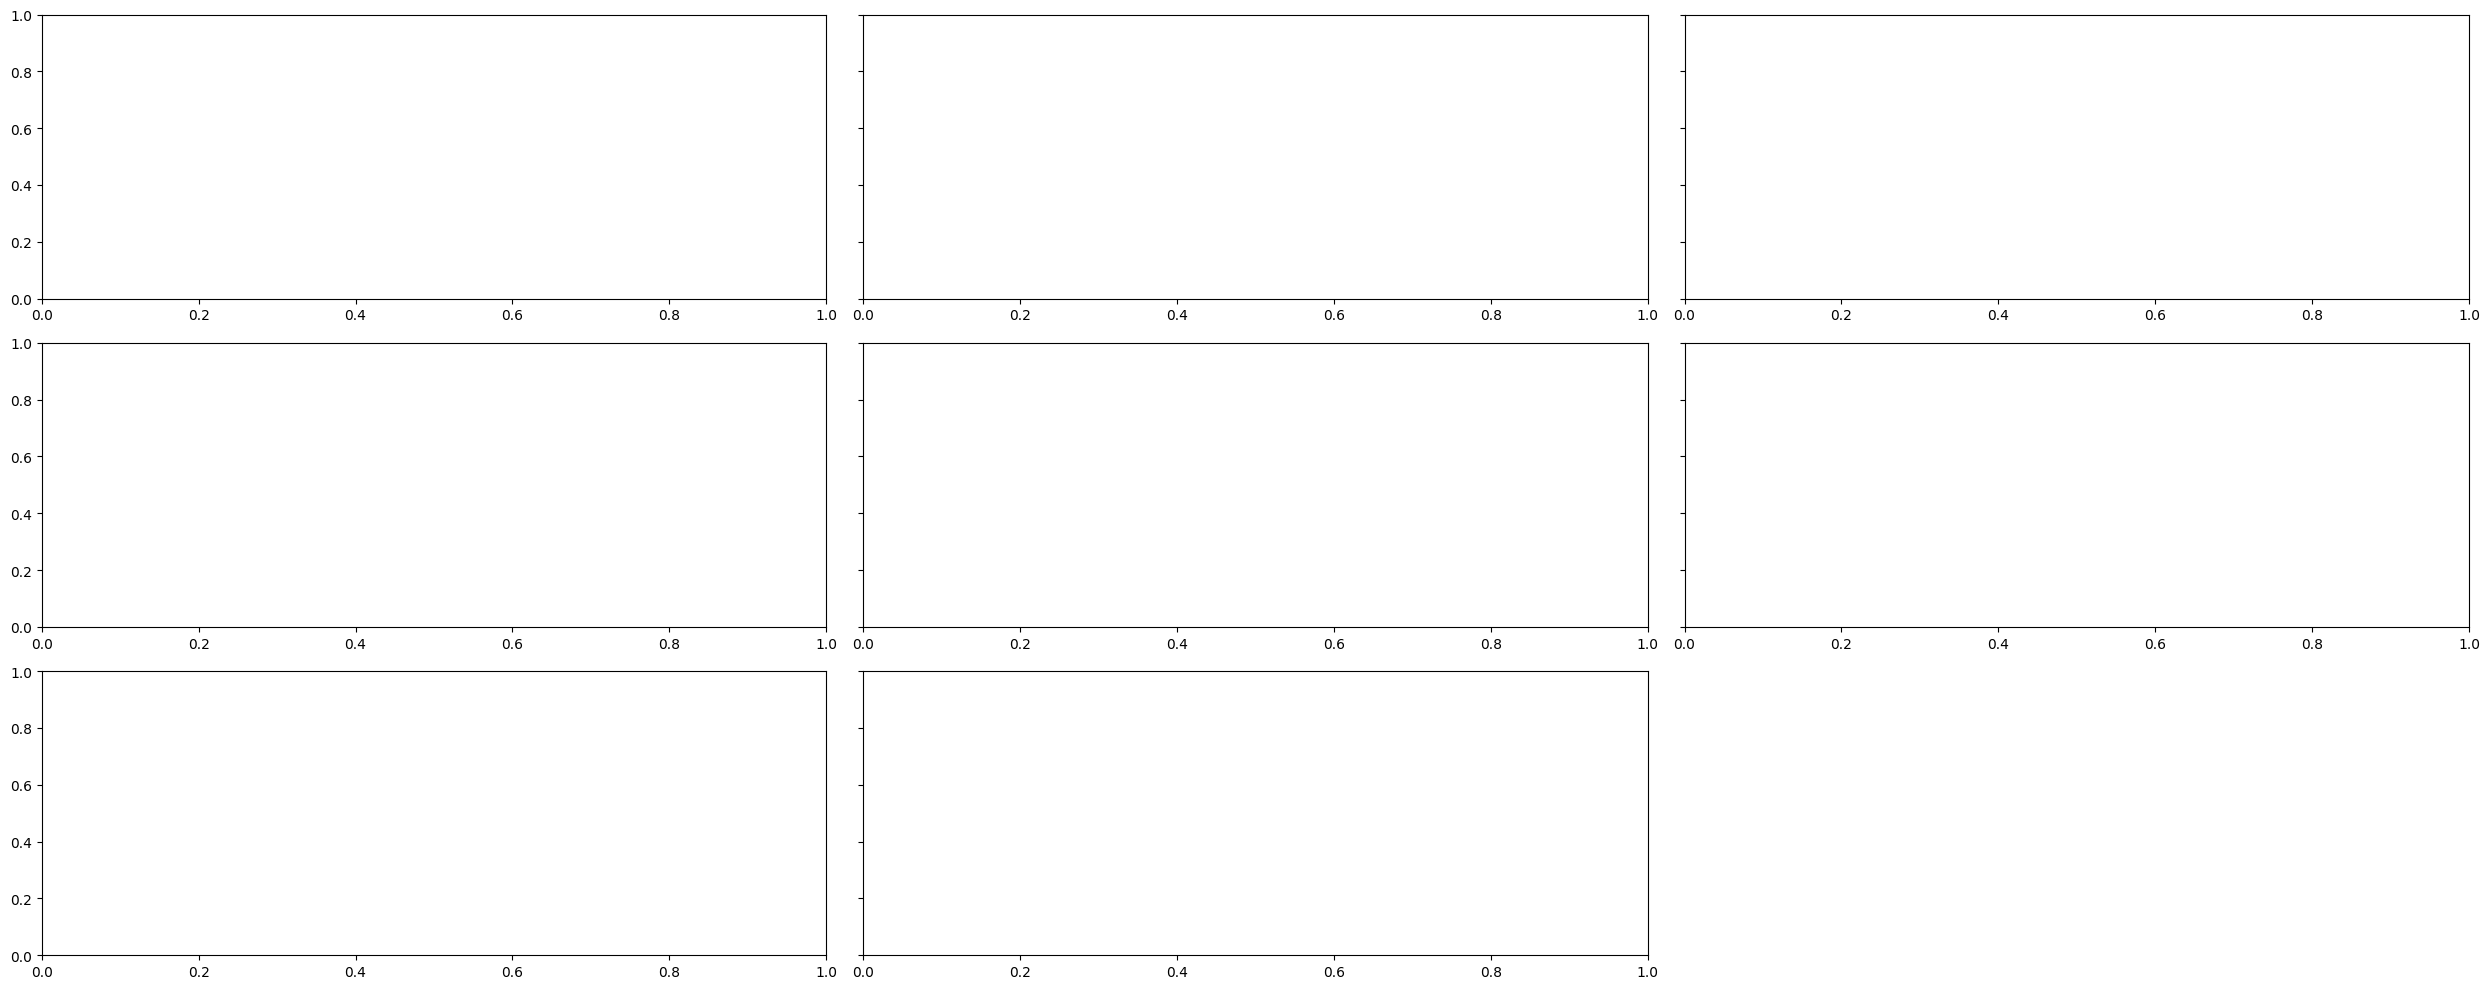

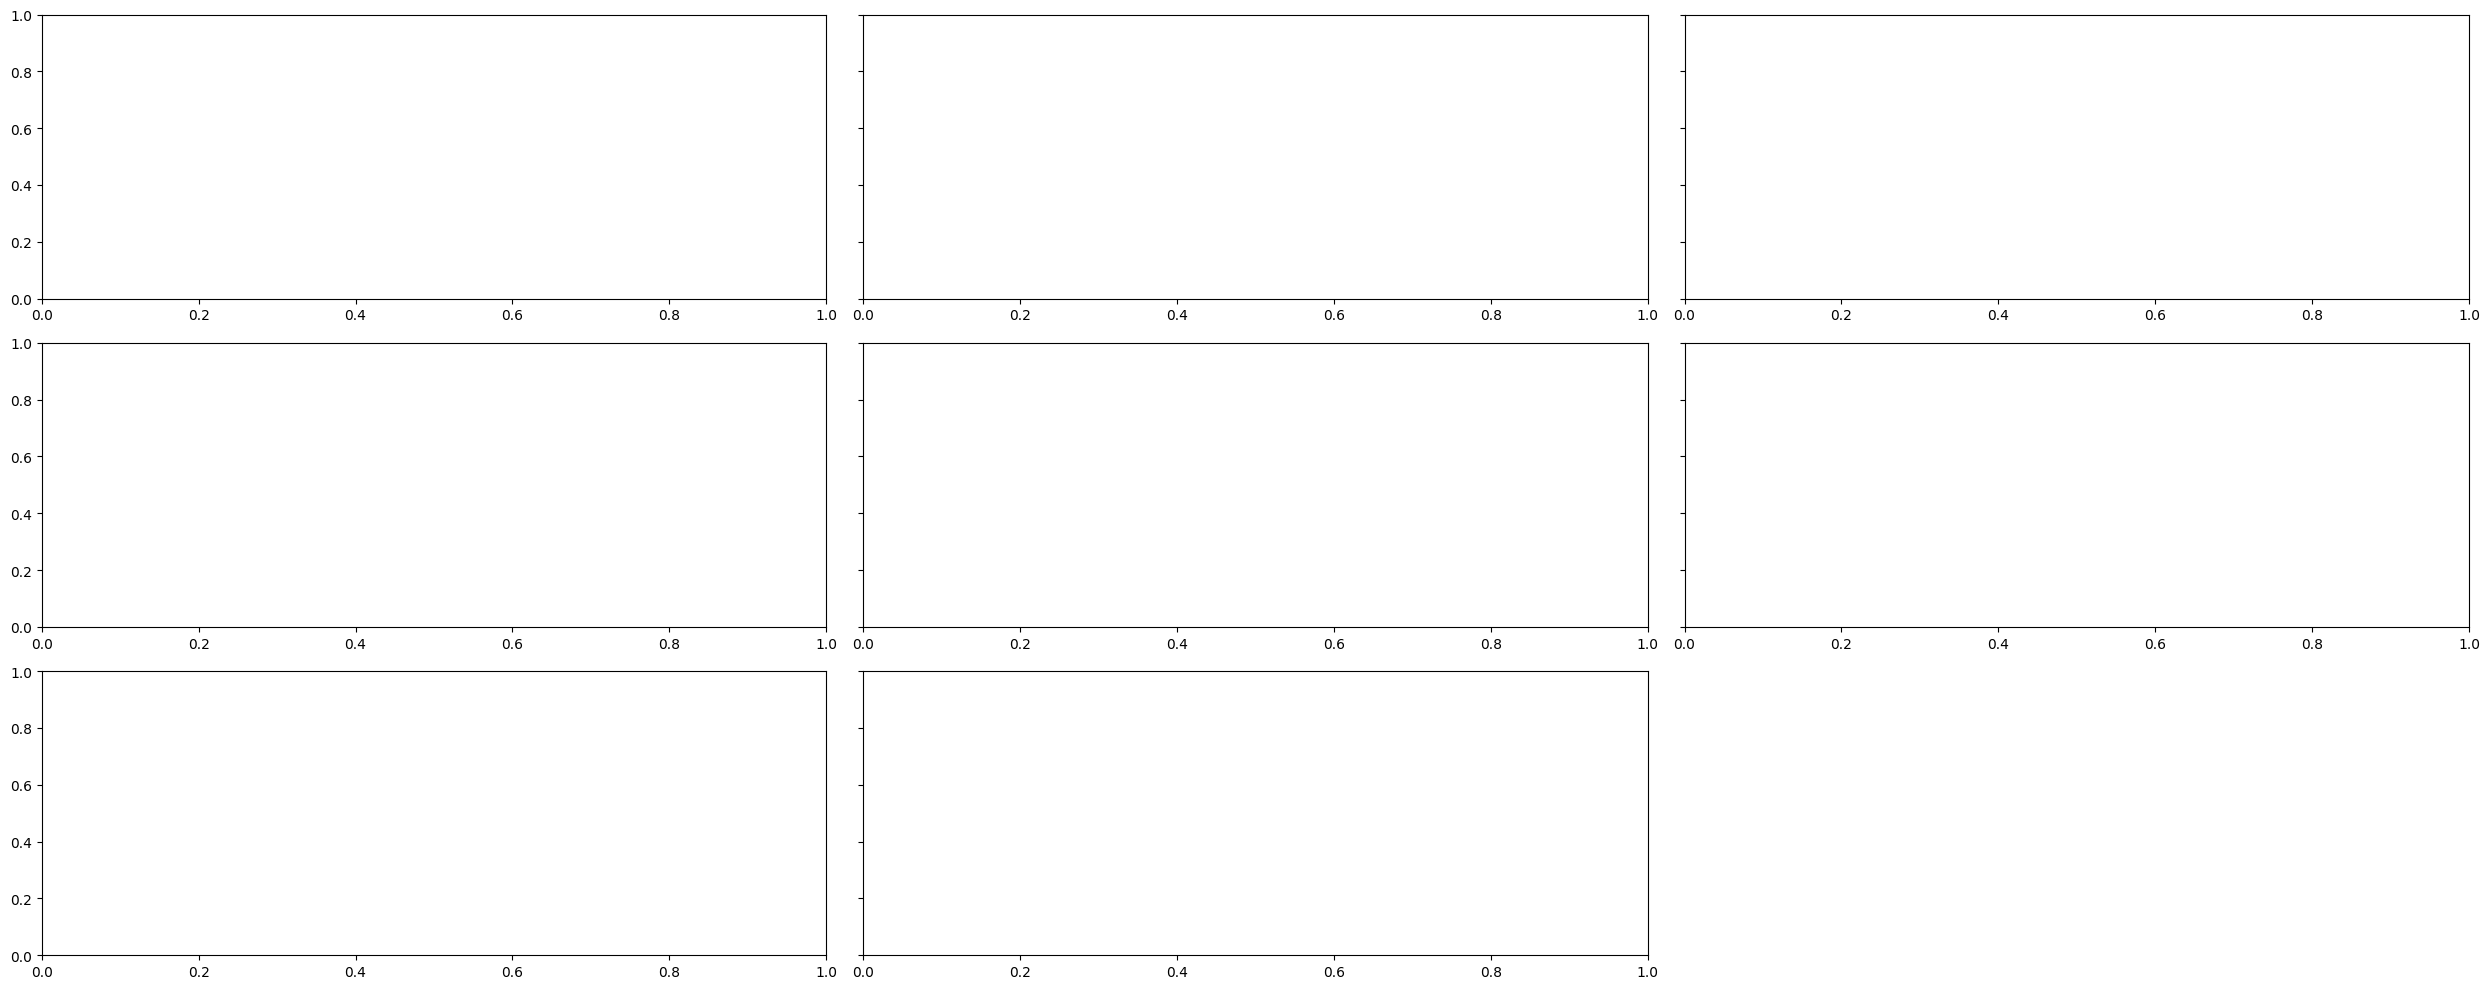

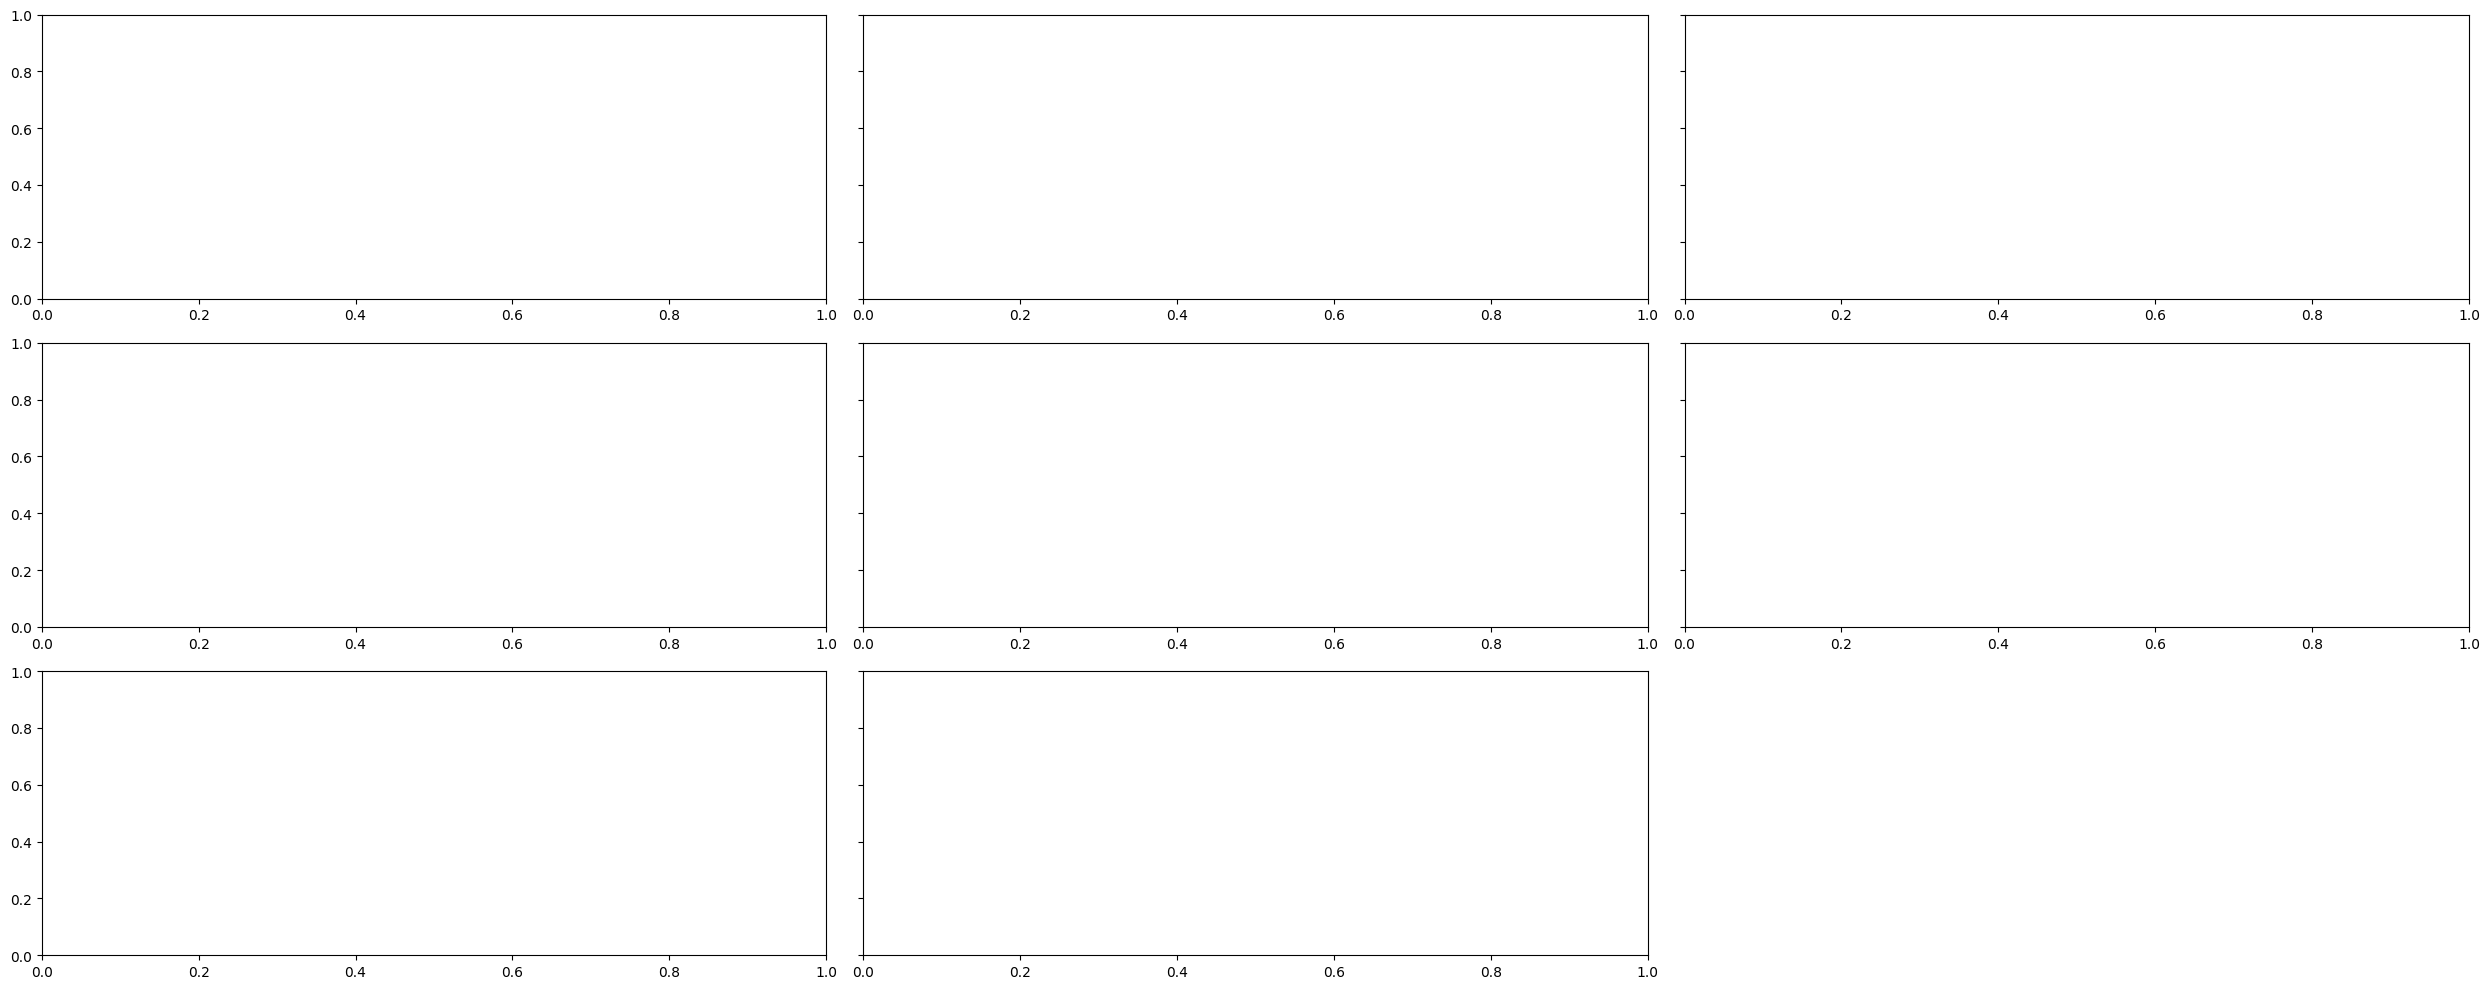


✓ Training complete!


In [8]:
if __name__ == "__main__":
    # Reload modules to pick up the fixed ray.get_actor() calls
    import importlib
    from gym_continuousDoubleAuction.train.plotter import plot_handler
    from gym_continuousDoubleAuction.train.logger import log_handler
    importlib.reload(plot_handler)
    importlib.reload(log_handler)
    from gym_continuousDoubleAuction.train.plotter.plot_handler import plot_storage
    from gym_continuousDoubleAuction.train.logger.log_handler import log_g_store
    
    config = get_config()
    experiment_id = go_train(config)
    
    # Plot results
    print("\nGenerating plots...")
    plot_storage(num_agents, init_cash)
    plot_storage(num_agents, init_cash, "step", "NAV")
    plot_storage(num_agents, init_cash, "step", "num_trades")
    
    # Save logs
    log_g_store(log_g_store_dir, num_agents, experiment_id)
    
    print("\n✓ Training complete!")